# Lagrangian-CVaR Comparison (Fixed $\lambda_{obs}$)

Train and compare two Lagrangian-CVaR controllers with `alpha_train` in `{1.0, 0.05}`.

This notebook keeps `lambda_search` unchanged and **does not** perform conformal/lambda hyperparameter tuning.

## Set-up

In [7]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, LagrangianCVaRLossWrapper
from training_function import train_agent
from plot_functions import plot_pb_trajectories

In [8]:
def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)


@dataclass
class ExperimentConfig:
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    seed: int = 4

    n_agents: int = 1
    state_dim: int = 4
    input_dim: int = 2
    dt: float = 0.05
    b_nom: float = 1.0
    m_nom: float = 1.0
    b2_nom: float = 0.2
    b_sim: float = 1.0
    m_sim: float = 1.0
    b2_sim: float = 0.2

    initialization_std: float = 0.01
    dim_internal: int = 4
    dim_nl: int = 4
    kp: float = 1.0
    ki: float = 1.0

    lambda_x: float = 4.0
    lambda_u: float = 0.0
    lambda_obs: float = 1.0
    tau_safe_bar: float = 0.0
    track_mode: str = "quadratic"
    coll_mode: str = "signed_distance"
    alpha_train: float = 0.05

    num_training_steps: int = 3000
    n_inner_steps: int = 5
    log_interval: int = 5
    early_stopping_patience_limit: int = 200
    gradient_clipping: float | None = None
    batch_size: int = 200
    horizon: int = 500
    lr: float = 0.001
    dual_lr_multiplier: float = 10.0
    dual_near_feasible_factor: float = 0.2
    dual_feasibility_margin: float = 0.02
    dual_far_feasible_factor: float = 2.0
    dual_far_violation_threshold: float = 0.1
    num_val_samples: int = 500
    num_plot_samples: int = 200

    def __post_init__(self):
        self.x0_centers = [[-2.0, -2.0], [1.0, -1.0], [0.0, 1.5]]
        self.x0_stds = [0.3, 0.1, 0.1]
        self.x0_probs = [0.5, 0.3, 0.2]

        self.Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * self.lambda_x
        self.Q = torch.kron(torch.eye(self.n_agents), self.Q_agent).to(self.device)

        self.R_agent = torch.eye(2) * self.lambda_u
        self.R = torch.kron(torch.eye(self.n_agents), self.R_agent).to(self.device)

        self.obs_centers = [torch.tensor([0.0, 0.6]), torch.tensor([-1.0, -1.0])]
        self.obs_radii = [[0.8, 0.1], [0.3, 0.3]]
        self.safety_factor = 1.0
        self.obs_radii_safe = [[r * self.safety_factor for r in obs] for obs in self.obs_radii]

        self.x_target = torch.zeros(4 * self.n_agents).to(self.device)


def build_training_objects(config: ExperimentConfig):
    sim_OL_plant = RobotPlant(b=config.b_sim, b2=config.b2_sim, m=config.m_sim, n_agents=config.n_agents).to(config.device)
    nominal_OL_plant = RobotPlant(b=config.b_nom, b2=config.b2_nom, m=config.m_nom, n_agents=config.n_agents).to(config.device)
    base_controller = PDController(kp=config.kp, ki=config.ki, n_agents=config.n_agents).to(config.device)

    f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(config.device)
    f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(config.device)

    for param in f_sim.parameters():
        param.requires_grad = False
    for param in f_nom.parameters():
        param.requires_grad = False

    ren = ContractiveREN(
        dim_in=config.state_dim * config.n_agents,
        dim_out=config.input_dim * config.n_agents,
        dim_internal=config.dim_internal,
        dim_nl=config.dim_nl,
        initialization_std=config.initialization_std,
    ).to(config.device)
    sim = PBClosedLoop(ren, f_sim, f_nom).to(config.device)

    metric = PBLoss(
        x_target=config.x_target,
        Q=config.Q,
        R=config.R,
        lambda_obs=config.lambda_obs,
        obs_centers=config.obs_centers,
        obs_radii_safe=config.obs_radii_safe,
        n_agents=config.n_agents,
        track_mode=config.track_mode,
        coll_mode=config.coll_mode,
    ).to(config.device)

    lag_cvar_wrapper = LagrangianCVaRLossWrapper(
        alpha=config.alpha_train,
        tau_safe_bar=config.tau_safe_bar,
        metric=metric
    ).to(config.device)

    return sim, metric, lag_cvar_wrapper


def compute_maximum_violation(traj_x: torch.Tensor, config: ExperimentConfig) -> torch.Tensor:
    x_reshaped = traj_x.view(traj_x.shape[0], traj_x.shape[1], config.n_agents, 4)
    pos = x_reshaped[..., :2]

    obs_centers_t = torch.stack(config.obs_centers).to(config.device)
    obs_radii_safe_t = torch.tensor(config.obs_radii_safe, dtype=torch.float32, device=config.device)

    centers = obs_centers_t.view(1, 1, 1, -1, 2)
    diff = pos.unsqueeze(3) - centers
    r_safe = obs_radii_safe_t.view(1, 1, 1, -1, 2)

    eps = 1e-12
    rho = torch.linalg.norm(diff / (r_safe + eps), dim=-1)
    rho_safe = torch.clamp(rho, min=eps)
    border_point = centers + diff / rho_safe.unsqueeze(-1)

    unsigned_dist = torch.linalg.norm(pos.unsqueeze(3) - border_point, dim=-1)
    signed_dist = torch.where(rho < 1.0, unsigned_dist, -unsigned_dist)

    min_safe_radius = r_safe.min(dim=-1).values.expand_as(signed_dist)
    signed_dist = torch.where(rho < 1e-9, min_safe_radius, signed_dist)

    maximum_violation = signed_dist.amax(dim=(1, 2, 3))
    return maximum_violation


def evaluate_model(sim, metric, val_w, config: ExperimentConfig):
    sim.eval()
    with torch.no_grad():
        traj_x_val, traj_u_val, _ = sim.run(val_w)
        _, cost_x_val, cost_u_val, _ = metric(traj_x_val, traj_u_val)

    perf_qr = cost_x_val + cost_u_val
    maximum_violation = compute_maximum_violation(traj_x_val, config)

    return {
        "mean_perf_qr": perf_qr.mean().item(),
        "violation_quantile_95": torch.quantile(maximum_violation, 0.95).item(),
        "violation_rate": (maximum_violation > 0.0).float().mean().item(),
        "maximum_violation": maximum_violation.detach().cpu(),
    }

## Shared Training Runner

In [9]:
alpha_values = [1.0, 0.05]

ExperimentConfig.noise_std = 0.0

set_seed(4)
base_cfg = ExperimentConfig(alpha_train=alpha_values[0])
fixed_val_w = generate_random_batch(base_cfg, custom_batch_size=base_cfg.num_val_samples)

save_dir = "lagrangian_cvar_checkpoints"
os.makedirs(save_dir, exist_ok=True)

runs = {}

def run_alpha_experiment(alpha: float, seed_offset: int):
    print("=" * 90)
    print(f"Training Lagrangian-CVaR with alpha_train={alpha}")

    set_seed(seed_offset)
    cfg = ExperimentConfig(alpha_train=alpha)
    sim, metric, lag_cvar_wrapper = build_training_objects(cfg)

    plot_kwargs = {
        "plot_func": plot_pb_trajectories,
        "x_target": cfg.x_target,
        "obs_centers": cfg.obs_centers,
        "obs_radii": cfg.obs_radii,
        "obs_radii_safe": cfg.obs_radii_safe,
        "dt": cfg.dt,
    }

    history, trajs = train_agent(
        config=cfg,
        sim=sim,
        loss_wrapper=lag_cvar_wrapper,
        mode="lagrangian_cvar",
        fixed_val_w=fixed_val_w,
        generate_random_batch=generate_random_batch,
        plot_results=True,
        plot_kwargs=plot_kwargs,
    )

    metrics = evaluate_model(sim, metric, fixed_val_w, cfg)

    alpha_tag = str(alpha).replace(".", "p")
    ckpt_path = f"{save_dir}/lagrangian_cvar_alpha_{alpha_tag}.pt"
    torch.save(
        {
            "alpha_train": alpha,
            "sim_state_dict": sim.state_dict(),
            "config": cfg.__dict__,
            "metrics": {
                "mean_perf_qr": metrics["mean_perf_qr"],
                "violation_quantile_95": metrics["violation_quantile_95"],
                "violation_rate": metrics["violation_rate"],
            },
        },
        ckpt_path,
    )

    run_data = {
        "config": cfg,
        "sim": sim,
        "metric": metric,
        "history": history,
        "trajs": trajs,
        "metrics": metrics,
        "ckpt_path": ckpt_path,
    }
    runs[alpha] = run_data

    print(
        f"alpha={alpha:.2f} | mean_perf_qr={metrics['mean_perf_qr']:.6f} | "
        f"q95_violation={metrics['violation_quantile_95']:.6f} | "
        f"violation_rate={metrics['violation_rate']:.2%}"
    )
    print(f"saved model: {ckpt_path}")

    return run_data

## Alpha = 1.0 (Train + Training Curves + Trajectory)

Training Lagrangian-CVaR with alpha_train=1.0
Starting LAGRANGIAN_CVAR online training on cpu...


Lagrangian Cvar: 100%|██████████| 3000/3000 [1:48:53<00:00,  2.18s/it, Perf=0.92, Viol=0.0112, Best=0.92]   



Restored best model (Metric: 0.9201).


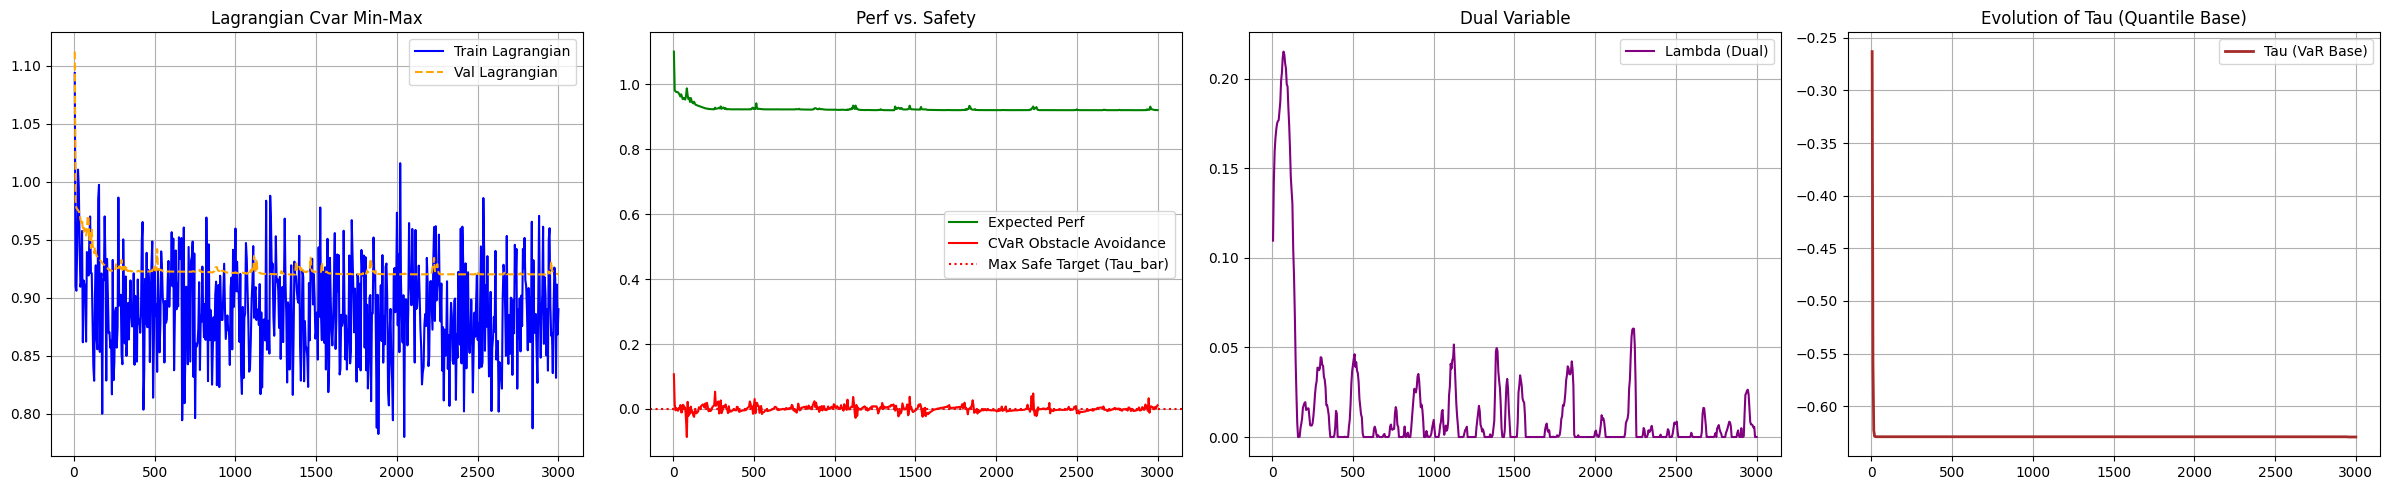

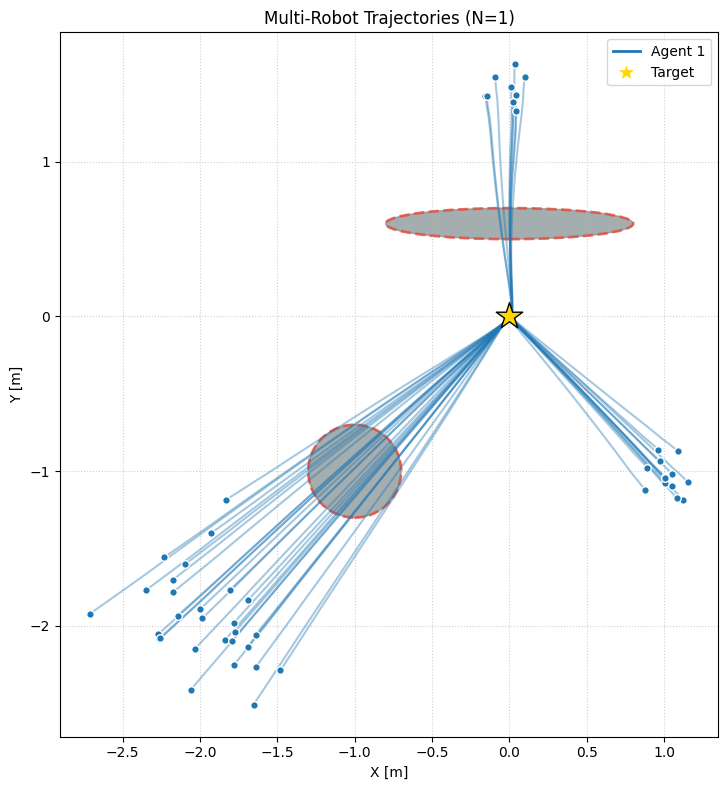

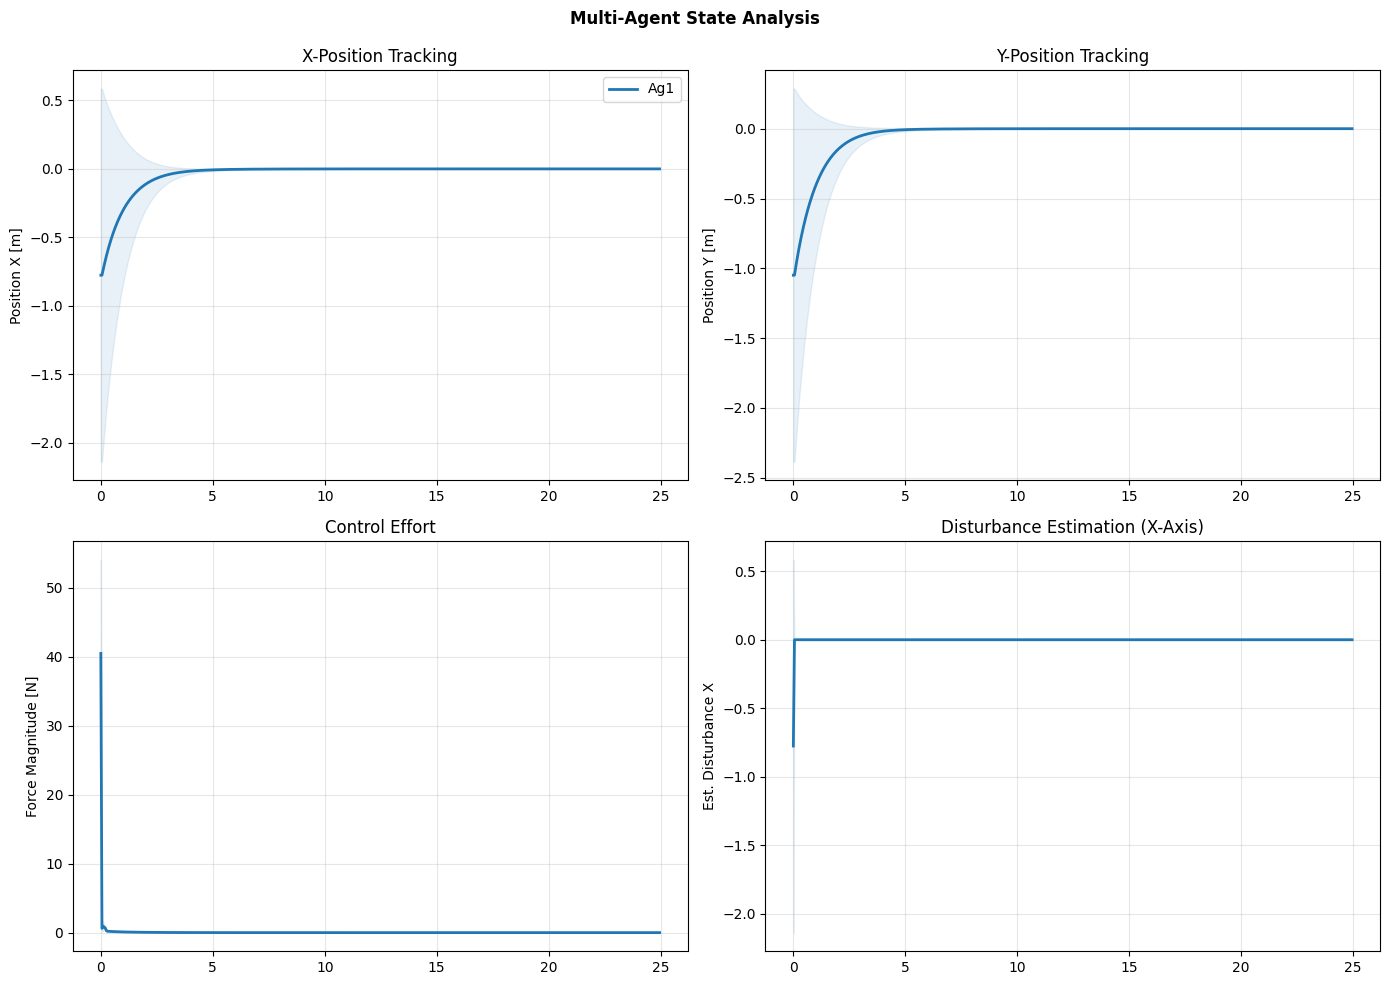

alpha=1.00 | mean_perf_qr=0.920136 | q95_violation=0.343807 | violation_rate=67.20%
saved model: lagrangian_cvar_checkpoints/lagrangian_cvar_alpha_1p0.pt


In [10]:
run_alpha_1 = run_alpha_experiment(alpha=1.0, seed_offset=10)


Alpha 0.05
Training Lagrangian-CVaR with alpha_train=0.05
Starting LAGRANGIAN_CVAR online training on cpu...


Lagrangian Cvar: 100%|██████████| 3000/3000 [1:47:12<00:00,  2.14s/it, Perf=1.06, Viol=0.0091, Best=1.05]     



Restored best model (Metric: 1.0513).


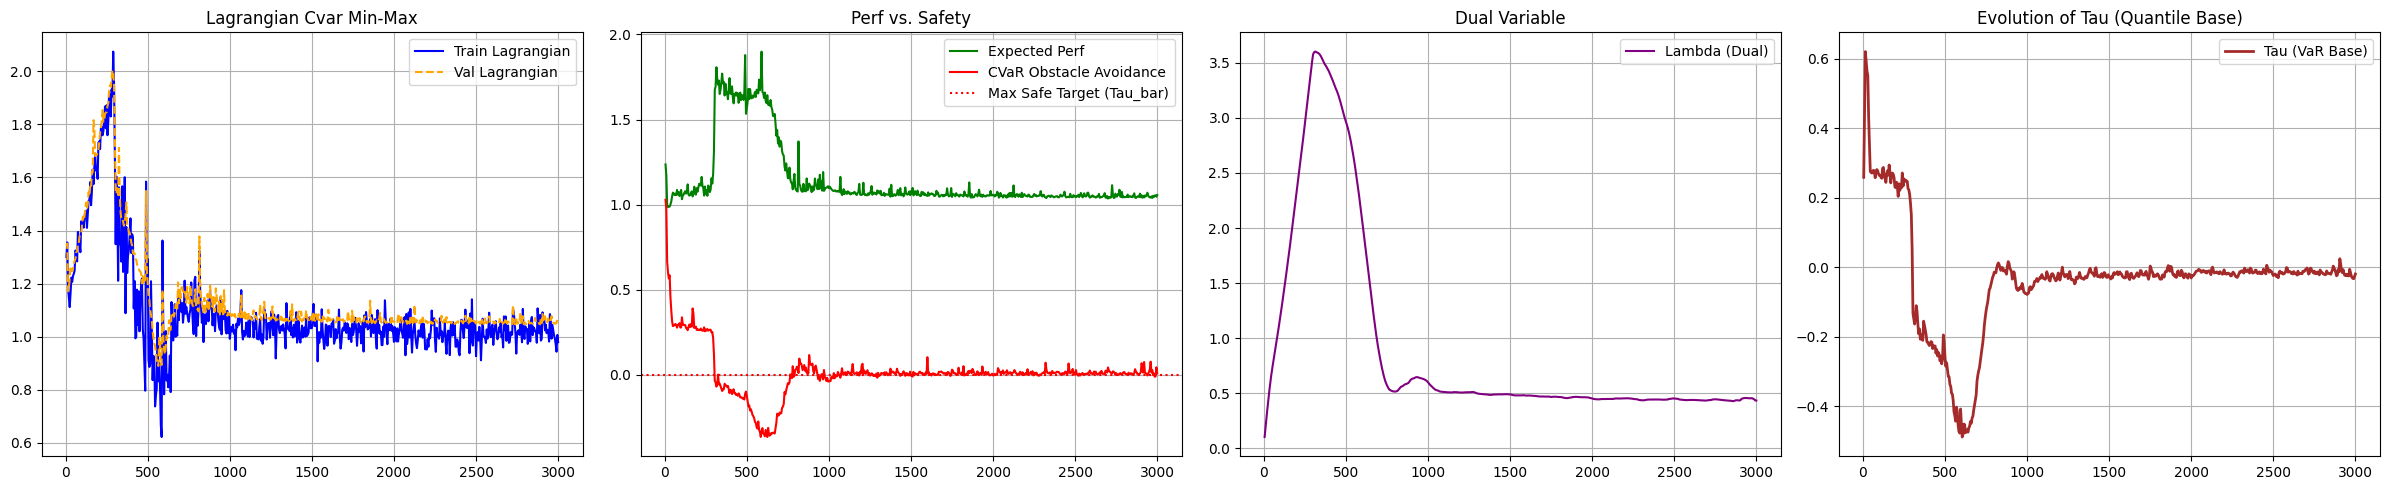

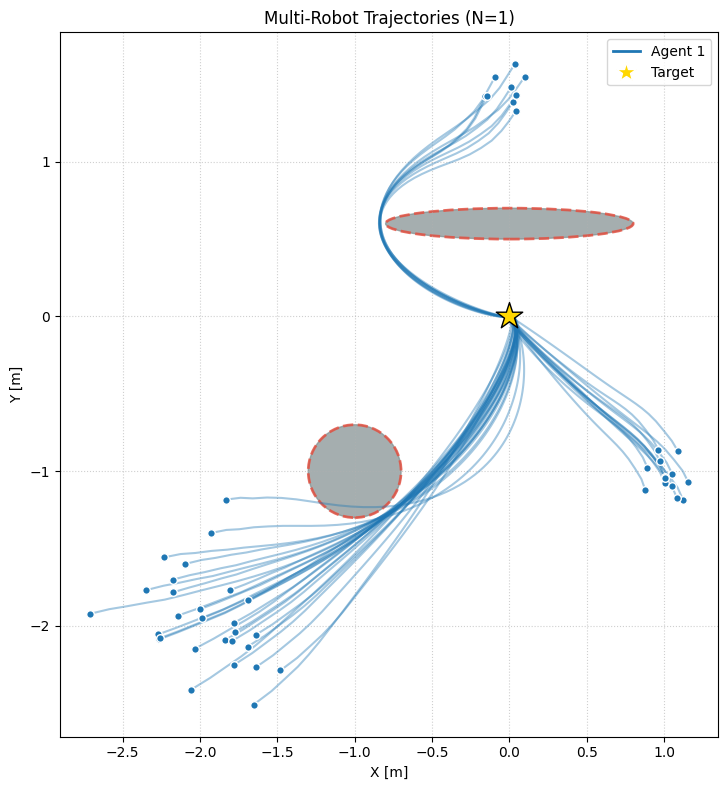

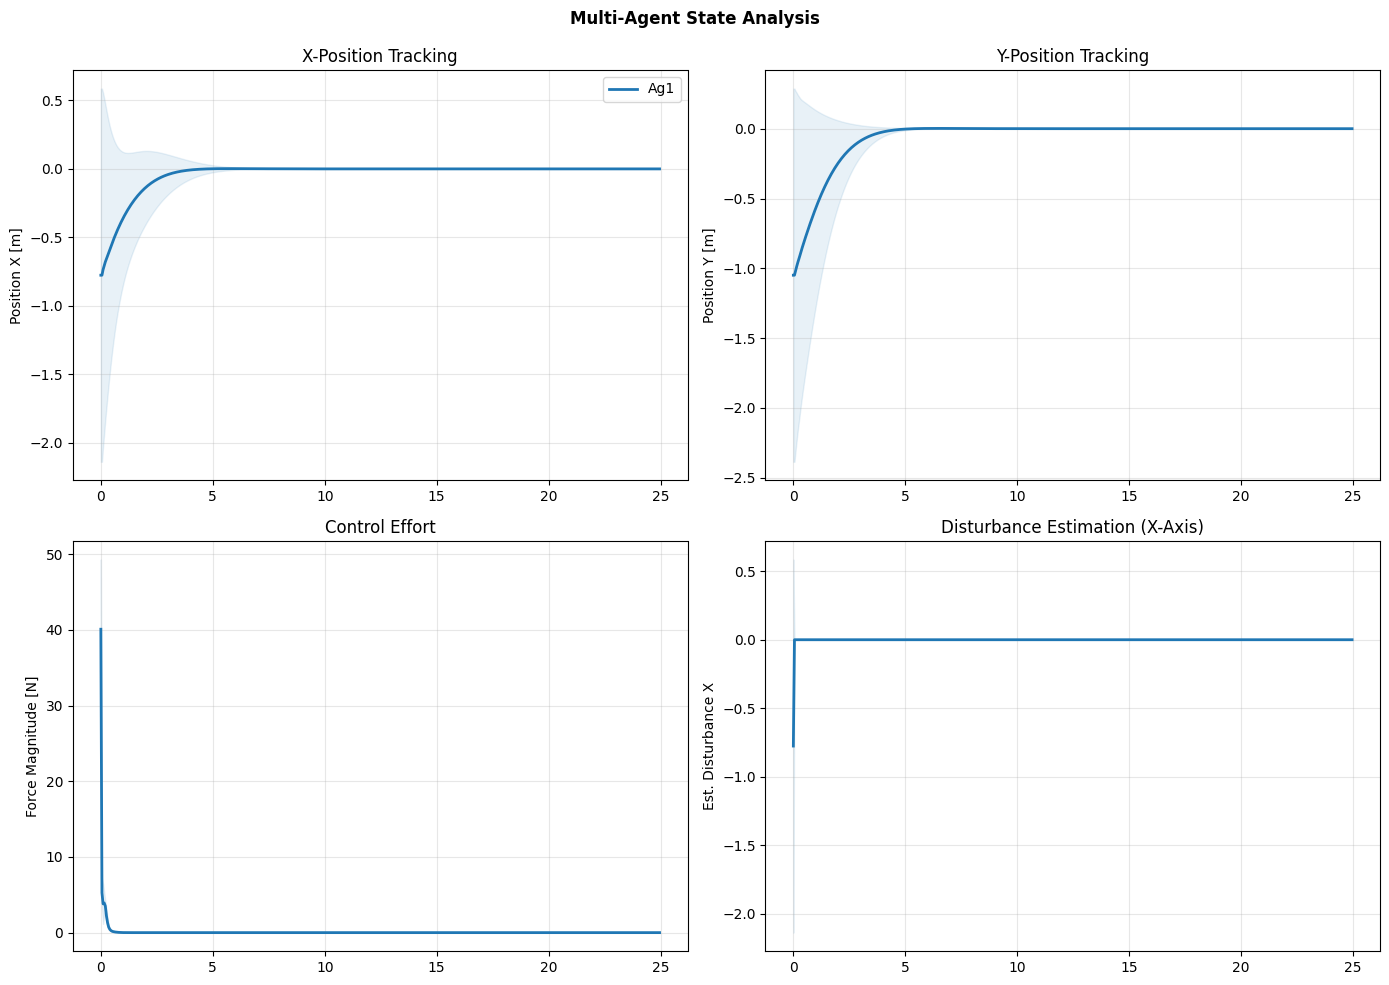

alpha=0.05 | mean_perf_qr=1.051298 | q95_violation=-0.032560 | violation_rate=1.40%
saved model: lagrangian_cvar_checkpoints/lagrangian_cvar_alpha_0p05.pt


In [11]:
print("\n" + "=" * 90)
print("Alpha 0.05")
run_alpha_005 = run_alpha_experiment(alpha=0.05, seed_offset=11)

Final validation comparison (fixed lambda_obs):
------------------------------------------------------------------------------------------
 alpha_train |   mean_perf_qr |     viol_q95 |  viol_rate |                         checkpoint
------------------------------------------------------------------------------------------
       1.000 |       0.920136 |     0.343807 |    67.20% | lagrangian_cvar_checkpoints/lagrangian_cvar_alpha_1p0.pt
       0.050 |       1.051298 |    -0.032560 |     1.40% | lagrangian_cvar_checkpoints/lagrangian_cvar_alpha_0p05.pt
------------------------------------------------------------------------------------------


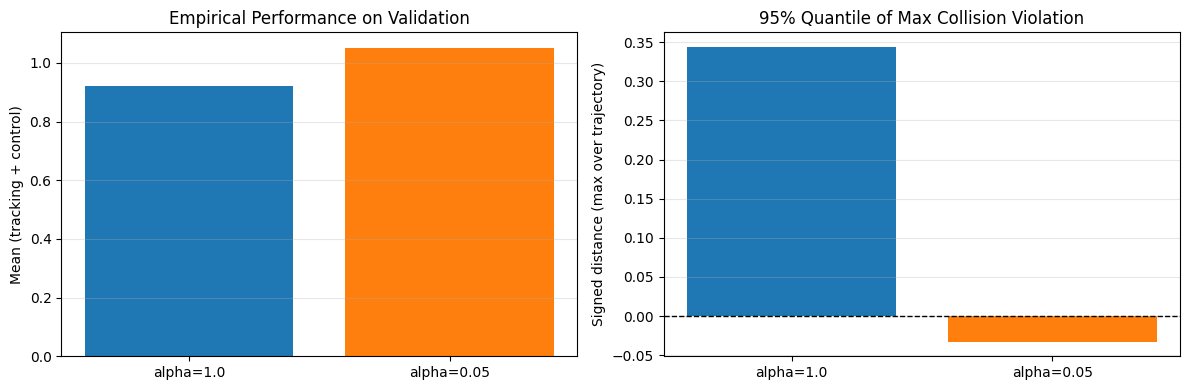

In [12]:
print("Final validation comparison (fixed lambda_obs):")
print("-" * 90)
print(f"{'alpha_train':>12} | {'mean_perf_qr':>14} | {'viol_q95':>12} | {'viol_rate':>10} | {'checkpoint':>34}")
print("-" * 90)

for alpha in alpha_values:
    r = runs[alpha]["metrics"]
    ckpt = runs[alpha]["ckpt_path"]
    print(
        f"{alpha:>12.3f} | {r['mean_perf_qr']:>14.6f} | {r['violation_quantile_95']:>12.6f} | "
        f"{r['violation_rate']:>9.2%} | {ckpt:>34}"
    )

print("-" * 90)

means = [runs[a]["metrics"]["mean_perf_qr"] for a in alpha_values]
q95s = [runs[a]["metrics"]["violation_quantile_95"] for a in alpha_values]
labels = [f"alpha={a}" for a in alpha_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, means, color=['tab:blue', 'tab:orange'])
axes[0].set_title('Empirical Performance on Validation')
axes[0].set_ylabel('Mean (tracking + control)')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(labels, q95s, color=['tab:blue', 'tab:orange'])
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('95% Quantile of Max Collision Violation')
axes[1].set_ylabel('Signed distance (max over trajectory)')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()